In [ ]:
# PHASE 1 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes graphs appear inside notebook
%matplotlib inline

In [3]:
df = pd.read_csv("data/Unemployment.csv") #LOADING THE DATASET

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.shape

(768, 7)

In [6]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [9]:
df.isnull().sum() # from output 28 values are missing

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [12]:
#  # PHASE 2  : DATA CLEANING 
# df.columns : OUTPUT WE CAN SEE THAT SOME EXTRA SPACE BEFORE THE COLUMN NAME 
# df.isnull().sum() : Since all columns have exactly 28 missing values, there are likely 28 completely empty rows. We can safely remove them.

SyntaxError: invalid syntax (1429973265.py, line 2)

In [14]:
df.columns = df.columns.str.strip() # Remove Extra Spaces from Column Names
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [16]:
df = df.dropna() # This removes rows containing missing values.
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [17]:
 df.shape # BEFORE (768, 7) NOW , 768-28

(740, 7)

In [19]:
# Currently:
# Date → object
# But for time analysis, Python should understand dates.

# SO Convert Date Column to Datetime

df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


C:\Users\balla\AppData\Local\Temp\ipykernel_19032\1543289189.py:7: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [21]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,September


In [23]:
df.shape # added two more columns year and  month

(740, 9)

In [24]:
avg_unemployment = df['Estimated Unemployment Rate (%)'].mean() #average unemployment rate in India
print("Average Unemployment Rate:", avg_unemployment)

Average Unemployment Rate: 11.787945945945946


In [26]:
max_unemployment = df['Estimated Unemployment Rate (%)'].max()   # .max() - Returns the largest value.

print("Highest Unemployment Rate:", max_unemployment) 

Highest Unemployment Rate: 76.74


In [27]:
min_unemployment = df['Estimated Unemployment Rate (%)'].min()  #.min() - Returns the smallest value.
print("Lowest Unemployment Rate:", min_unemployment)

Lowest Unemployment Rate: 0.0


In [29]:
#Which state has the highest average unemployment?
state_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()   #groupby('Region') - Groups data state-wise.
state_unemployment.sort_values(ascending=False).head(10)  #sorts from highest to lowest 

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

In [30]:
state_unemployment.sort_values().head(10)

Region
Meghalaya         4.798889
Odisha            5.657857
Assam             6.428077
Uttarakhand       6.582963
Gujarat           6.663929
Karnataka         6.676071
Sikkim            7.249412
Madhya Pradesh    7.406429
Andhra Pradesh    7.477143
Maharashtra       7.557500
Name: Estimated Unemployment Rate (%), dtype: float64

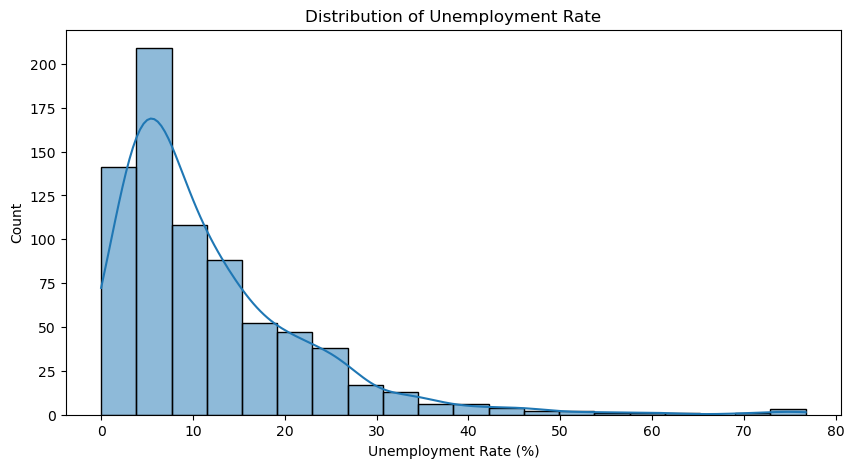

In [32]:
#Visualization 1: Distribution of Unemployment Rate
plt.figure(figsize=(10,5))
sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20, kde=True)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")

plt.show()

#This graph tells us : Most common unemployment values

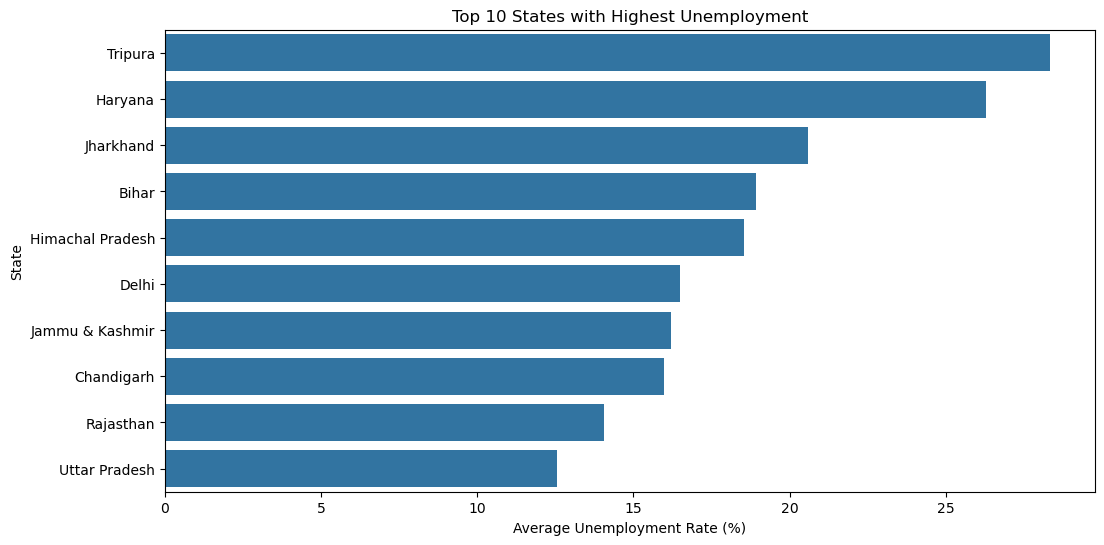

In [33]:
#Visualization 2: Top 10 States by Unemployment
top_states = state_unemployment.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_states.values, y=top_states.index)

plt.title("Top 10 States with Highest Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

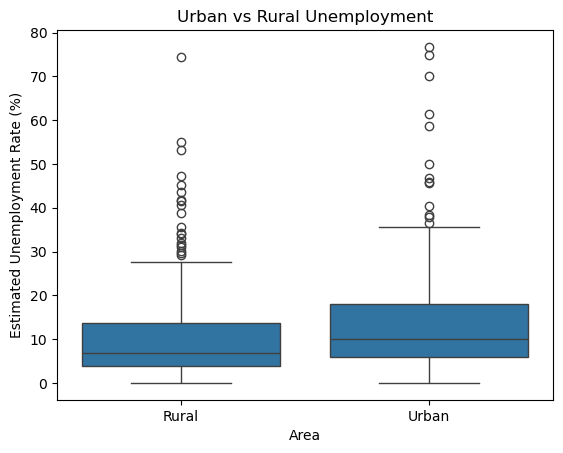

In [34]:
#Visualization 3: Area-wise Comparison
sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Urban vs Rural Unemployment")
plt.show()

In [35]:
# # Phase 4: COVID-19 Impact Analysis

# We will compare:
# Before COVID: Before March 2020
# During COVID: March 2020 and after

In [36]:
df['Covid_Period'] = df['Date'].apply(
    lambda x: 'Before Covid' if x < pd.Timestamp('2020-03-01')
    else 'During Covid'
)
df[['Date', 'Covid_Period']].head(10)

,Date,Covid_Period
0,2019-05-31,Before Covid
1,2019-06-30,Before Covid
2,2019-07-31,Before Covid
3,2019-08-31,Before Covid
4,2019-09-30,Before Covid
5,2019-10-31,Before Covid
6,2019-11-30,Before Covid
7,2019-12-31,Before Covid
8,2020-01-31,Before Covid
9,2020-02-29,Before Covid


In [37]:
covid_analysis = df.groupby('Covid_Period')[
    'Estimated Unemployment Rate (%)'
].mean()

print(covid_analysis)
# INCREASE OF 8% DURING THE COVID

Covid_Period
Before Covid     9.509534
During Covid    17.774363
Name: Estimated Unemployment Rate (%), dtype: float64


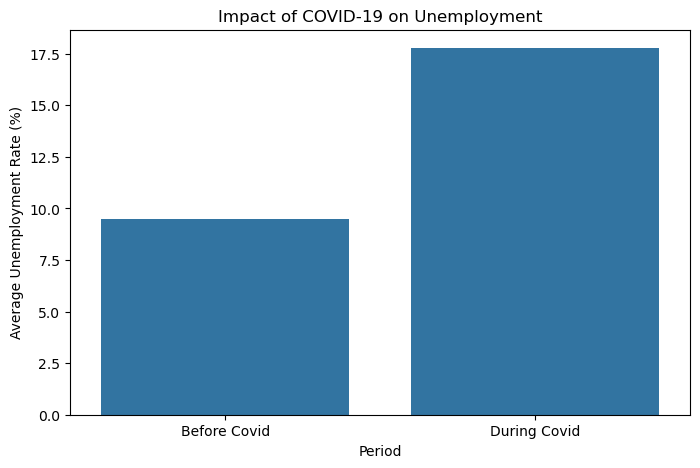

In [38]:
#Visualize COVID Impact

plt.figure(figsize=(8,5))

sns.barplot(
    x=covid_analysis.index,
    y=covid_analysis.values
)

plt.title("Impact of COVID-19 on Unemployment")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

In [40]:
monthly_unemployment = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

print(monthly_unemployment)

#Create monthly averages:You may notice some months consistently have higher unemployment.
#These are called seasonal trends.

# OUTPUT BECAUSE OF April 2020 was the period of strict nationwide lockdown in India.

Month
April        23.641569
August        9.637925
December      9.497358
February      9.964717
January       9.950755
July          9.033889
June         10.553462
March        10.700577
May          16.646190
November      9.868364
October       9.900909
September     9.051731
Name: Estimated Unemployment Rate (%), dtype: float64


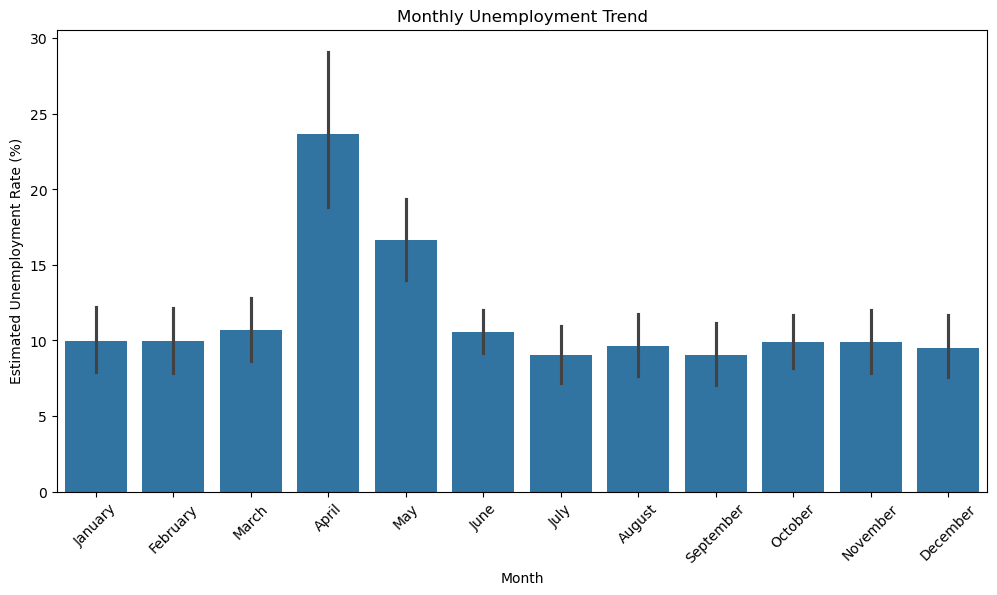

In [46]:
#Better Monthly Visualization
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='Month',
    y='Estimated Unemployment Rate (%)',
    order=month_order
)

plt.xticks(rotation=45)
plt.title("Monthly Unemployment Trend")

plt.show()

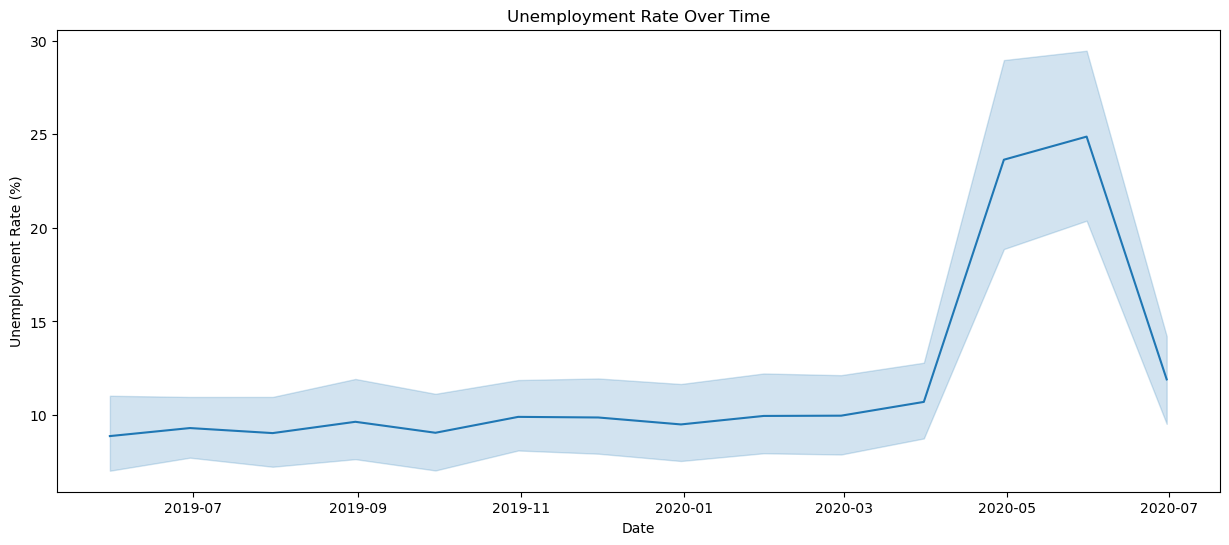

In [47]:
# Unemployment Trend Over Time

plt.figure(figsize=(15,6))

sns.lineplot(
    data=df,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [49]:
# Phase 5: Advanced Analysis and Visualization

In [ ]:
# What is Correlation?

# Correlation tells us how two variables are related.
# Positive correlation → both increase together
# Negative correlation → one increases while the other decreases
# Zero correlation → no relationship

In [50]:
correlation = df.select_dtypes(include=['float64']).corr()  # CREATE CORRELATION MATRIX

print(correlation)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


In [57]:
# Variables	                       Correlation
# Unemployment ↔ Employed	            0.222876
# Unemployment ↔ Labour Participation	0.002558
# Employed ↔ Labour Participation 	0.011300

# A. Unemployment vs Employment : Correlation = -0.222876 , NEGATIVE , As employment increases, unemployment tends to decrease.
# B. Unemployment vs Labour Participation Rate : Correlation = 0.002558, NEAR TO 0 , There is almost no relationship between unemployment rateand labour participation rate
# C. Employment vs Labour Participation Rate : Correlation = 0.011300 , NEAR TO 0 , NO RELATIONSHIP

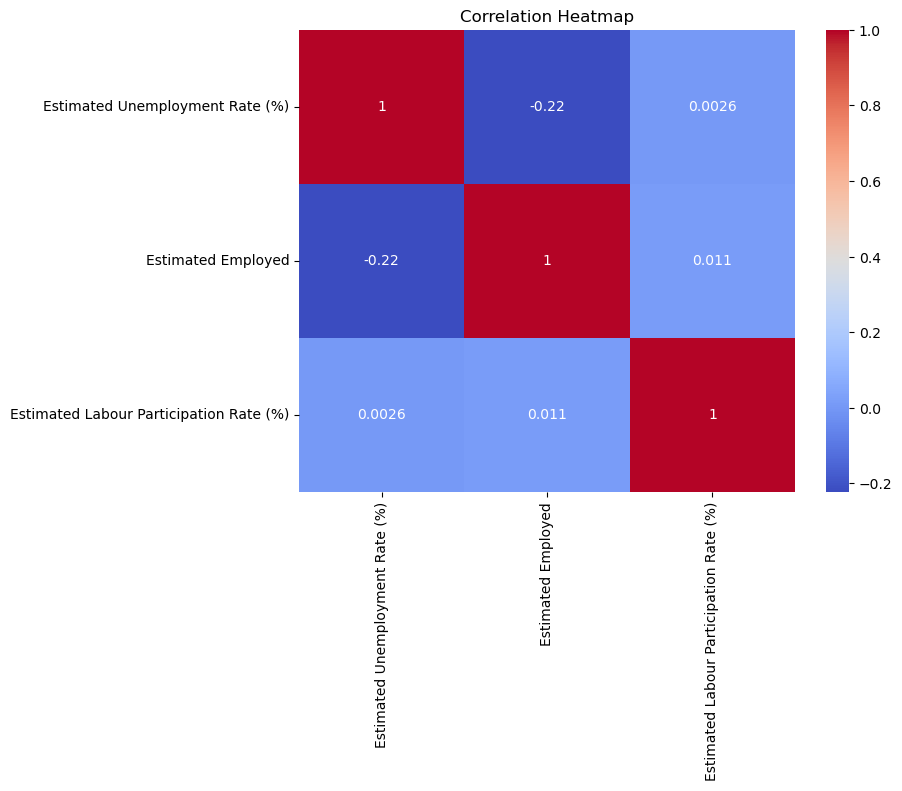

In [51]:
#Visualize Using Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [53]:
# State-wise COVID Impact

state_covid = df.groupby(
    ['Region', 'Covid_Period']
)['Estimated Unemployment Rate (%)'].mean().unstack()

print(state_covid.head())

#This compares each state's unemployment before and during COVID.

Covid_Period    Before Covid  During Covid
Region                                    
Andhra Pradesh      5.037500     13.576250
Assam               6.372632      6.578571
Bihar              13.833000     31.631250
Chandigarh         16.325000     14.325000
Chhattisgarh        7.706500     13.075000


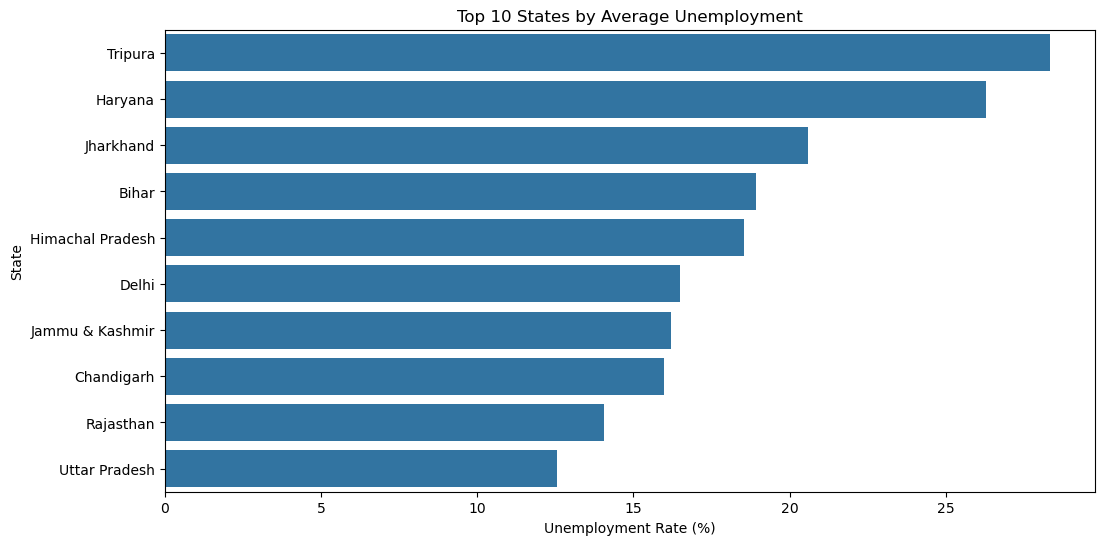

In [54]:
# Visualize Top 10 States

top10 = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States by Average Unemployment")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

In [55]:
#Urban vs Rural Analysis

area_analysis = df.groupby('Area')[
    'Estimated Unemployment Rate (%)'
].mean()

print(area_analysis)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


In [56]:
# If Urban > Rural: Urban areas were more affected by unemployment.
# If Rural > Urban: Rural areas experienced higher unemployment.

In [58]:
###   SUCESSFULLY COMPLETED ### 